In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [17]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

OOF score: 11.31109296893528
[445, 480, 1050, 804, 1076]


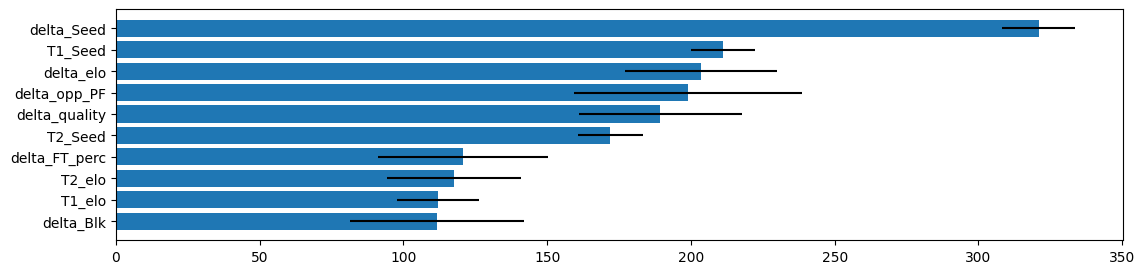

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


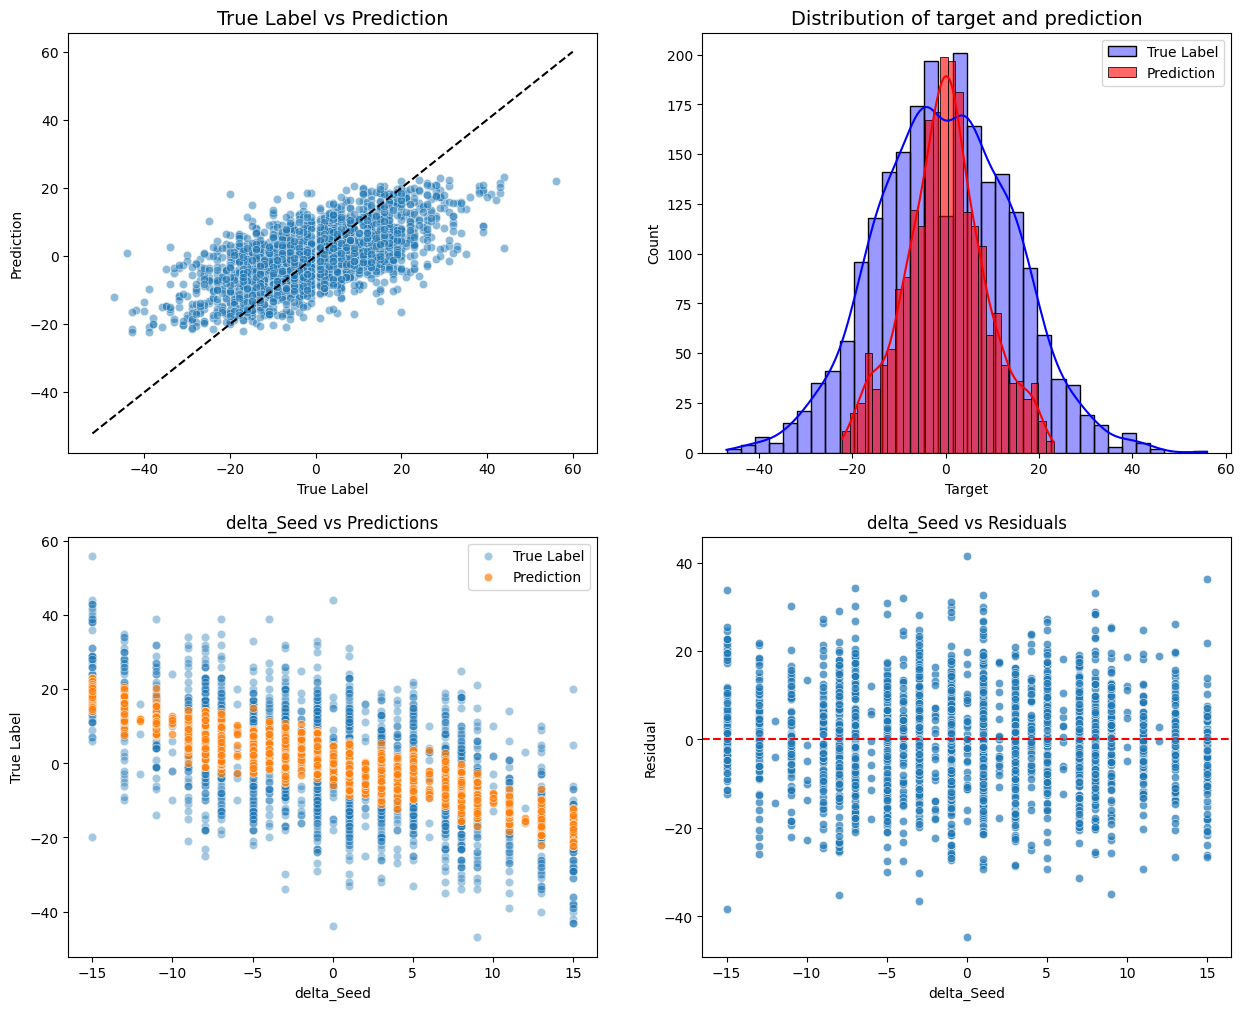

Test score: 12.058456348289804


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


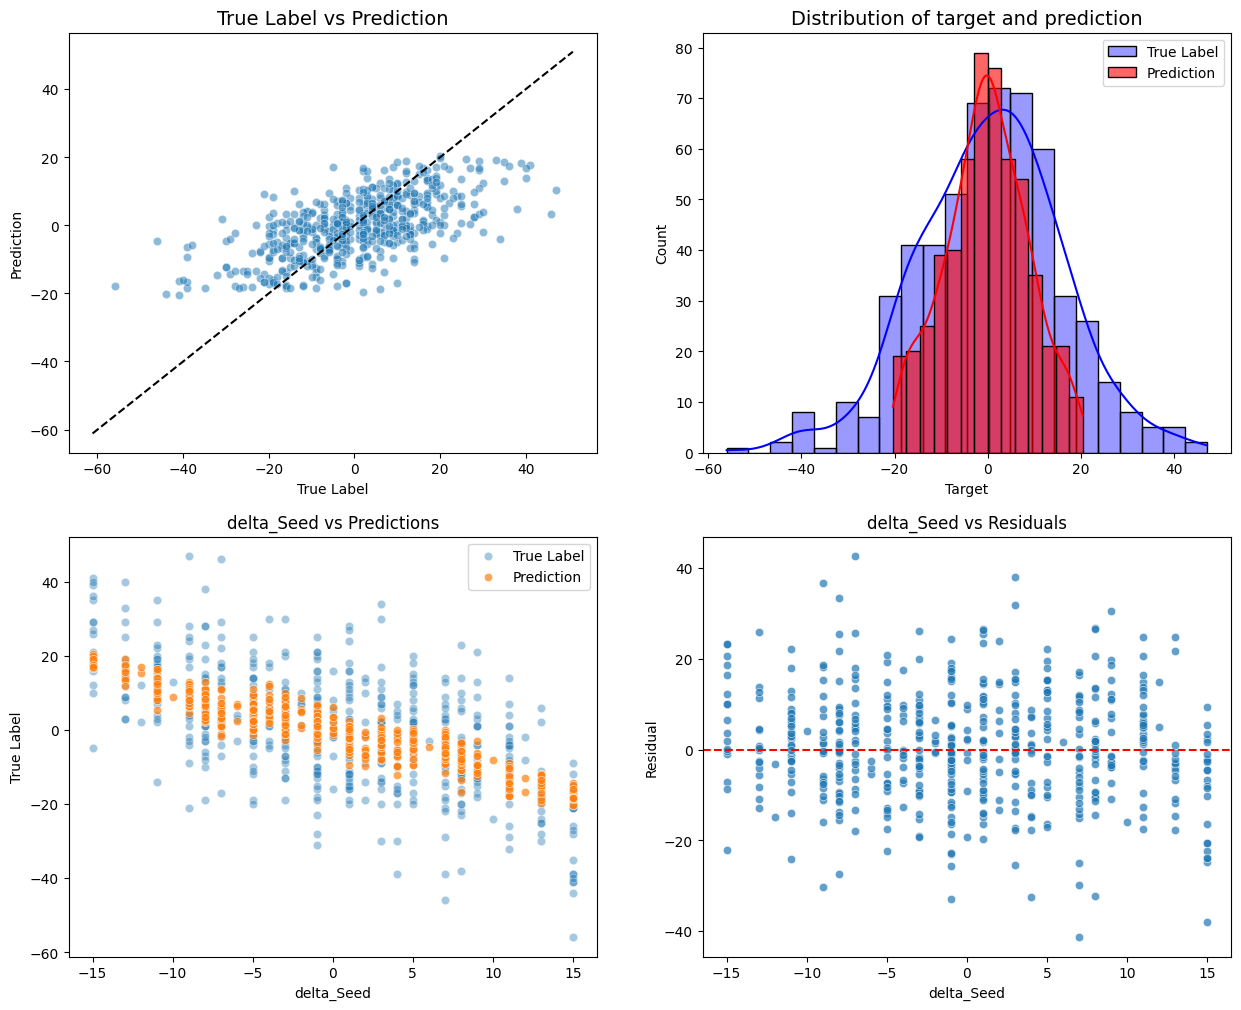

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


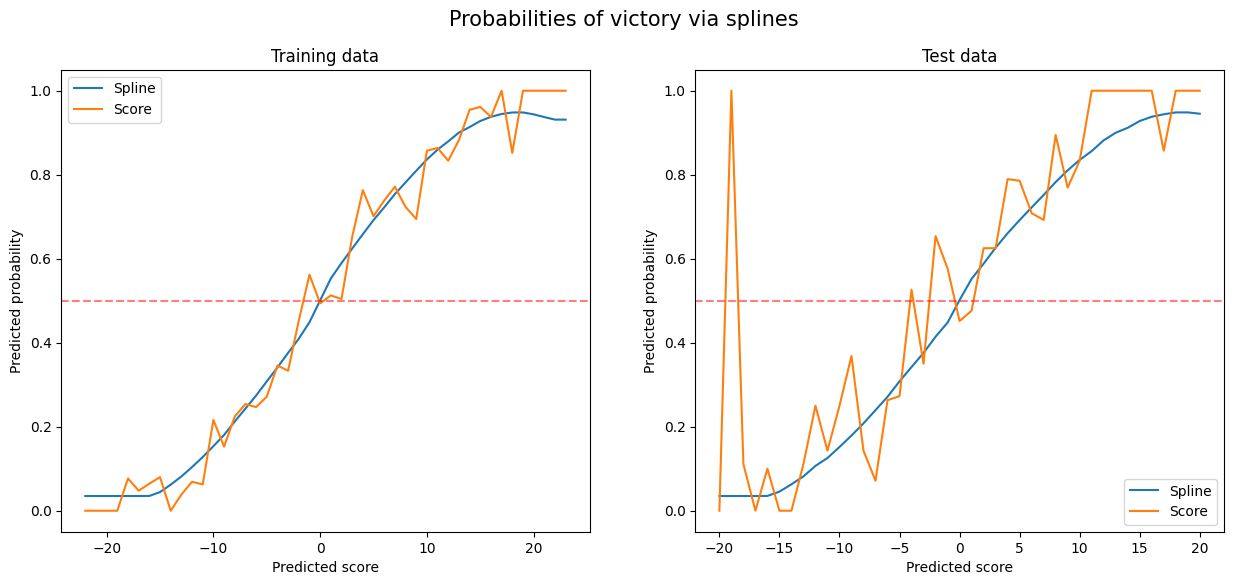

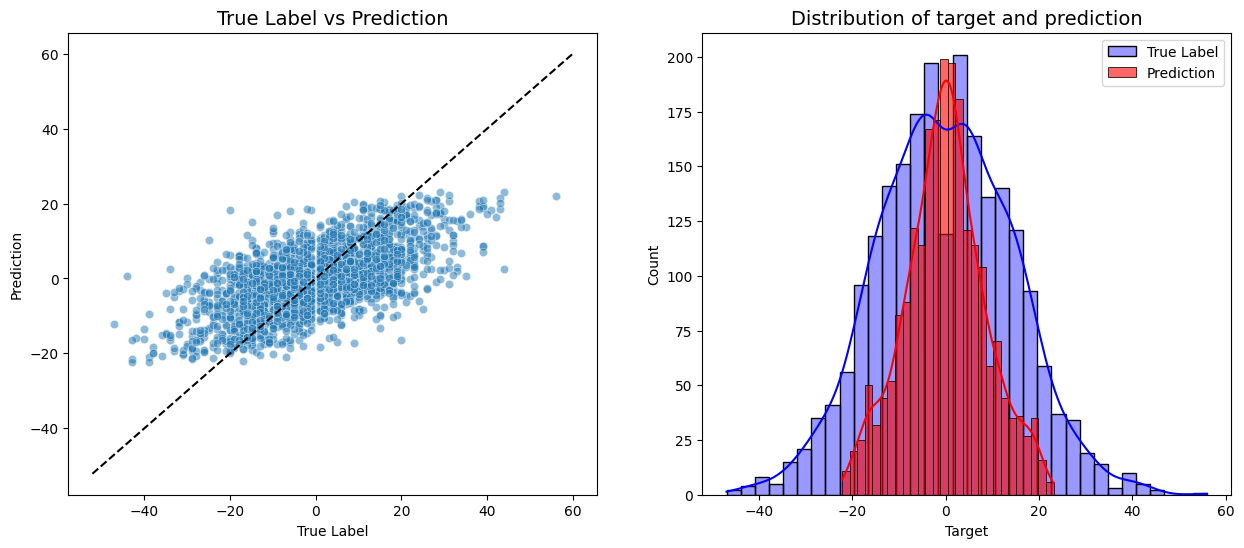

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


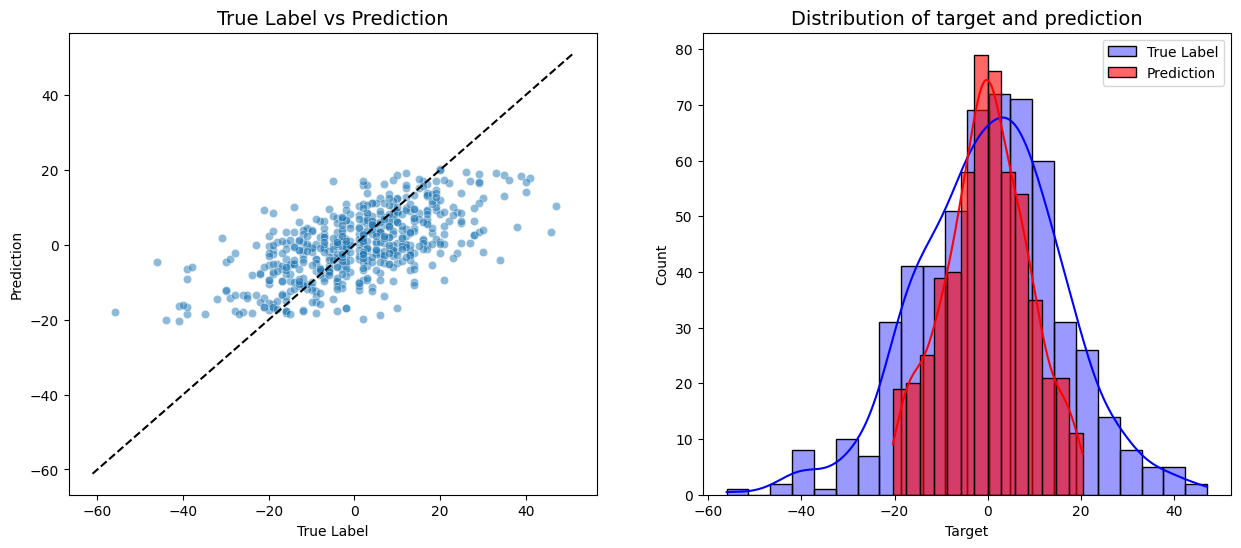

MAE train: 			 8.9477
MAE test: 			 9.3138
RMSE train: 			 11.3111
RMSE test: 			 12.0585
Accuracy train: 		 0.7061
Accuracy test: 			 0.705
Logloss train: 			 0.5454
Logloss test: 			 0.54
Brier train: 			 0.1853
Brier test: 			 0.1822
Unsure train: 			 21.74%
Unsure test: 			 19.6%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,8.9477,9.3138,11.3111,12.0585,0.7061,0.705,0.5454,0.54,0.1853,0.1822,21.74,19.6


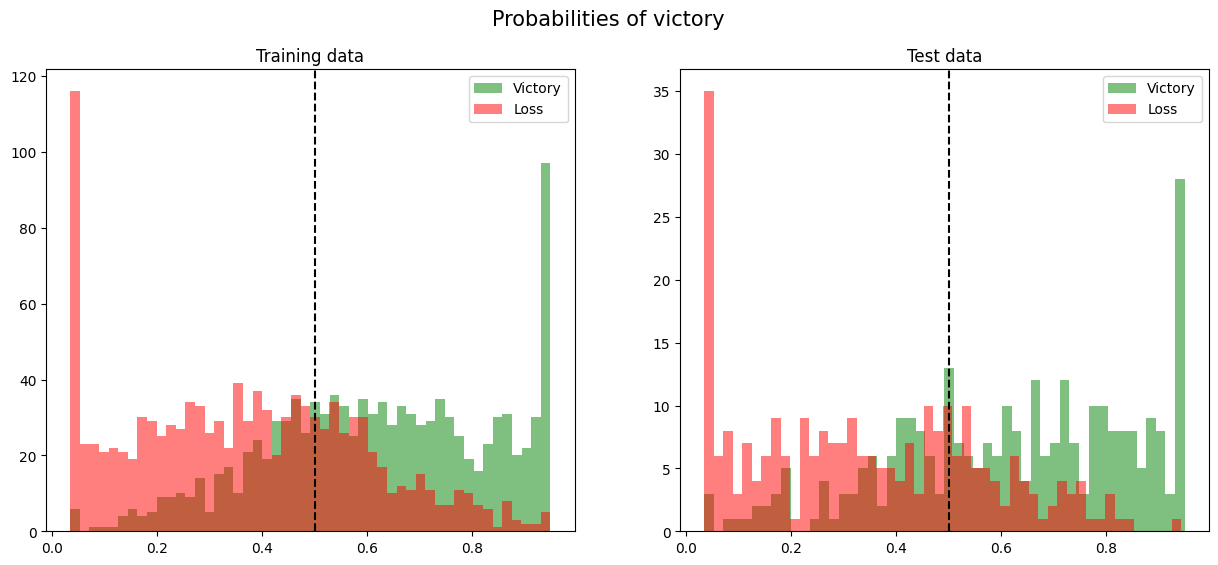

In [18]:
target = df_train["target_points"]

not_imp = [
 'delta_TO_diff',
 'T2_FGA3_diff',
 'T1_FTA',
 'delta_Ast_diff',
 'delta_Tot_Reb',
 'T2_TO_perposs',
 'delta_True_shooting_perc_diff',
 'delta_FGM2',
 'T1_def_rating',
 'T1_FGM_diff',
 'T2_FG3_ratio',
 'T1_opp_score',
 'T2_OR',
 'T2_FGM3',
 'T1_FGM_no_ast_diff',
 'T2_DR',
 'delta_opp_possessions',
 'T2_Tot_Reb',
 'T1_TO_diff',
 'delta_Tot_Reb_diff',
 'T2_FGA2_diff',
 'delta_OT_win',
 'T1_Ast',
 'delta_Ast',
 'T1_FG3_ratio_diff',
 'T2_FG3_ratio_diff',
 'T2_FGA',
 'T1_impact',
 'T1_Tot_Reb',
 'delta_possessions',
 'T1_DR',
 'T2_opp_FGM',
 'T2_Eff_shooting_perc',
 'T2_FT_perc',
 'delta_FTM_diff',
 'T2_Ast',
 'T1_OR_opportunity',
 'T1_FGM3_diff',
 'delta_def_edge',
 'delta_OR_opportunity_diff',
 'T2_FGA3',
 'T2_FGM2',
 'delta_FGM3',
 'T2_FGM_perc',
 'T1_OT_win',
 'T2_N_wins',
 'T2_impact_diff',
 'T2_FGA2',
 'delta_FG3_ratio',
 'T2_Ast_diff',
 'T2_FGM2_perc',
 'delta_def_rating',
 'T1_TO_perposs',
 'delta_DR_diff',
 'T2_Eff_FG_perc_diff',
 'T1_FTA_diff',
 'delta_FGM2_perc',
 'T2_OT_win_perc',
 'T2_OT_win',
 'T2_TO_perposs_diff',
 'delta_FGA3',
 'delta_FGA',
 'T2_FGM3_diff',
 'delta_OT_win_perc',
 'T2_FTM_diff',
 'delta_FGM2_diff',
 'T1_OT_win_perc',
 'stage_Round2',
 'T1_FGM2_perc',
 'stage_Round1',
 'stage_Round3',
 'stage_Round4',
 'stage_final',
 'stage_finalfour',
 'stage_impossible'
]

extras = ['T1_Seed',
 'T1_elo',
 'T2_Seed',
 'T2_elo',]
FEATURES = [c for c in df_train if  c not in DROP and c not in not_imp ] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = lgb.LGBMRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                          learning_rate=0.01,
                         max_depth=115, num_leaves=97,
                         reg_lambda=98, reg_alpha=64,
                         colsample_bytree=0.335, subsample=0.81,
                         min_child_weight=79.7, eval_metric="l2", verbose=-1)

pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "l2"}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=False, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=22, padd=0.035)

MAE train: 			 8.9565
MAE test: 			 9.3073
RMSE train: 			 11.3371
RMSE test: 			 12.0394
Accuracy train: 		 0.6976
Accuracy test: 			 0.7032
Logloss train: 			 0.5466
Logloss test: 			 0.5407
Brier train: 			 0.1857
Brier test: 			 0.1822
Unsure train: 			 21.11%
Unsure test: 			 18.88%

In [19]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=22, padd=0.035)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [20]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,9.067155,0.204243
True,8.831473,0.166770


In [21]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,8.899846,0.185769
True,9.088804,0.183733


In [22]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,8.913066,0.180365
True,9.188095,0.219157


In [23]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,8.945804,0.180508
True,8.976473,0.256366


In [24]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,8.926295,0.184533
True,9.569720,0.206170


In [25]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,8.961446,0.185007
True,8.064630,0.201067


In [12]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18568681473527862
1 0.18568681473527862
2 0.18569743803393893
3 0.18571161445158071
4 0.18572606089622518
5 0.18574077736787234
6 0.18575657701792678
7 0.18577300366059107
8 0.18579003984669695
9 0.1858131739362273
10 0.1858395560323877
11 0.18586208513794858
12 0.18587765073453158
13 0.18589264002714523
14 0.18590936827953433
15 0.18592333341442513
16 0.18593657460141674
17 0.1859561725758245
18 0.18598063543412044
19 0.18600876324690171
20 0.1860391412847055
21 0.18607176954753177
22 0.18610741210388182
23 0.18614710280777735
24 0.1861859416916657


Round1 + 2%
Round2 + 2%
finalfour + 2%

In [13]:
tmp = df_train.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 2 / 100) & (tmp["stage_Round2"]), "oof_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 2 / 100) & (tmp["stage_Round2"]), "oof_prob"] = 0.5 - 2 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 2 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 2 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 - 2 / 100
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 2 / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 2 / 100) & (tmp["stage_finalfour"]), "oof_prob"] = 0.5 - 2 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2
tmp["sqr_err_prob"].mean()


0.18568681473527862


0.18562923636824605

In [14]:
tmp = df_test.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 2 / 100) & (tmp["stage_Round2"]), "pred_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 2 / 100) & (tmp["stage_Round2"]), "pred_prob"] = 0.5 - 2 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 2 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 2 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 - 2 / 100
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 2 / 100) & (tmp["stage_finalfour"]), "pred_prob"] = 0.5 + 2 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 2 / 100) & (tmp["stage_finalfour"]), "pred_prob"] = 0.5 - 2 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["pred_prob"])**2
tmp["sqr_err_prob"].mean()

0.18216250963483638


0.18218419880824446

In [26]:
df_train.to_csv("data/results/men_train_lgb.csv", index=False)
df_test.to_csv("data/results/men_test_lgb.csv", index=False)